**Pipeline:**
1. User uploads image (Streamlit)
2. Decode image (OpenCV / PIL)
3. YOLOv8 detects cattle → bounding boxes + detection confidence
4. For each bounding box:  
    a. Crop cattle region  
    b. Preprocess crop (resize + normalize)  
    c. Breed classification model predicts breed + confidence  
5. Draw bounding boxes + breed labels on image
6. Display annotated image + results in Streamlit

## Section 0
1. Loading the dataset
2. Data transformation functions
3. Creating a subset and remapping the dataset to the selected breeds
4. Train and Validation set split

In [1]:
# imports
import numpy as np
import os

from torchvision import transforms
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [2]:
DATASET_DIR = "/kaggle/input/indian-cattle-image-dataset/cattle"
print(len(os.listdir(DATASET_DIR)))
print(os.listdir(DATASET_DIR)[:50])

50
['Purnea', 'motu', 'Himachali Pahari', 'kherigarh', 'ghumsari', 'gaolao', 'Dangi', 'Sahiwal', 'Kankrej', 'Hariana', 'nagori', 'Pulikulam', 'Kosali', 'Kangayam', 'bhelai', 'Konkan Kapila', 'Shweta Kapila', 'Kenkatha', 'Nimari', 'ponwar', 'Lakhimi', 'Vechur', 'Krishna_Valley', 'Nari', 'Hallikar', 'Punganur', 'Amritmahal', 'Tharparkar', 'Khariar', 'Khillari', 'Ayrshire', 'badri', 'thutho', 'Red_Sindhi', 'siri', 'Deoni', 'Bargur', 'Poda Thirupu', 'bachaur', 'Ongole', 'Malnad_gidda', 'dagri', 'Ladakhi', 'Mewati', 'Gir', 'Rathi', 'gangatari', 'Umblachery', 'Red kandhari', 'malvi']


In [3]:
# counting number of images per breed
breed_counts = []
total = 0
for breed in os.listdir(DATASET_DIR):
    path = os.path.join(DATASET_DIR, breed)
    if(os.path.isdir(path)):
        count = len(os.listdir(path))
        breed_counts.append((breed, count))
        total = total + count

breed_counts.sort(key = lambda x: x[1], reverse=True)
for b, c in breed_counts[:15]:
    print(b, c)

print("Total images in the entire dataset", total)

Sahiwal 421
Gir 353
Purnea 274
Umblachery 255
Ayrshire 233
Shweta Kapila 231
Mewati 230
ponwar 225
Tharparkar 212
Ongole 191
thutho 184
siri 184
Red kandhari 184
motu 183
nagori 183
Total images in the entire dataset 8539


In [4]:
# Preprocessing
from torchvision import transforms

IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
])

In [5]:
# Another look at the dataset
from torchvision.datasets import ImageFolder

full_dataset = ImageFolder(DATASET_DIR, transform=None)
print(len(full_dataset))
print(full_dataset.classes)

8531
['Amritmahal', 'Ayrshire', 'Bargur', 'Dangi', 'Deoni', 'Gir', 'Hallikar', 'Hariana', 'Himachali Pahari', 'Kangayam', 'Kankrej', 'Kenkatha', 'Khariar', 'Khillari', 'Konkan Kapila', 'Kosali', 'Krishna_Valley', 'Ladakhi', 'Lakhimi', 'Malnad_gidda', 'Mewati', 'Nari', 'Nimari', 'Ongole', 'Poda Thirupu', 'Pulikulam', 'Punganur', 'Purnea', 'Rathi', 'Red kandhari', 'Red_Sindhi', 'Sahiwal', 'Shweta Kapila', 'Tharparkar', 'Umblachery', 'Vechur', 'bachaur', 'badri', 'bhelai', 'dagri', 'gangatari', 'gaolao', 'ghumsari', 'kherigarh', 'malvi', 'motu', 'nagori', 'ponwar', 'siri', 'thutho']


In [6]:
# Filtering the dataset by selecting the top 15 breeds with most number of images
selected_breeds = [b for b,_ in breed_counts[:15]]
selected_ids = [
    i for i, (_, label) in enumerate(full_dataset.samples)
    if full_dataset.classes[label] in selected_breeds
]
from torch.utils.data import Subset
filtered_dataset = Subset(full_dataset, selected_ids)
print("Size of filtered dataset: ",len(filtered_dataset))

breed_to_new_label = {
    breed: i for i, breed in enumerate(selected_breeds)
}


Size of filtered dataset:  3543


In [7]:
from torch.utils.data import Dataset

class RemappedDataset(Dataset):
    def __init__(self, subset, full_classes, selected_breeds, transform=None):
        self.subset = subset
        self.full_classes = full_classes
        self.transform = transform
        self.breed_to_new = {
            breed: i for i, breed in enumerate(selected_breeds)
        }

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, old_label = self.subset[idx]
        breed_name = self.full_classes[old_label]
        new_label = self.breed_to_new[breed_name]

        if self.transform is not None:
            image = self.transform(image)

        return image, new_label


In [8]:
# train and test set split
from torch.utils.data import random_split
import torch

train_dataset = RemappedDataset(
    filtered_dataset,
    full_dataset.classes,
    selected_breeds,
    transform=train_tf
)

val_dataset = RemappedDataset(
    filtered_dataset,
    full_dataset.classes,
    selected_breeds,
    transform=val_tf
)

val_ratio = 0.15
val_size = int(len(train_dataset) * val_ratio)
train_size = len(train_dataset) - val_size

generator = torch.Generator().manual_seed(42)
train_indices, val_indices = random_split(
    range(len(train_dataset)),
    [train_size, val_size],
    generator=generator
)

train_ds = torch.utils.data.Subset(train_dataset, train_indices)
val_ds   = torch.utils.data.Subset(val_dataset, val_indices)

## Section 1
### Breed Classifier
1. Loading the pretrained efficient net
2. Setting the batch size
3. Training for 6 loops and displaying the result

In [9]:
# Loading Efficient Net
import torch.nn as nn
from torchvision import models

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, len(selected_breeds))


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 171MB/s]


In [10]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

In [11]:
# Dividing the train set and test set into batches
from torch.utils.data import DataLoader
batch_size = 32
train_loader = DataLoader(train_ds, batch_size = batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

print("Train batches: ", len(train_loader))
print("Val batches: ", len(val_loader))

Train batches:  95
Val batches:  17


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ", device)
model = model.to(device)

Device:  cuda


In [13]:
# Single Train function
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim = 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# Validation loop
@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim = 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [14]:
# Training the model
import copy

EPOCHS = 6
best_val_acc = 0
best_model_wts = copy.deepcopy(model.state_dict())
best_epoch = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)
    
    print(f"Epoch {epoch + 1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Epoch {epoch + 1}: New best model saved with accuracy: {val_acc:.4f}")

Epoch 1/6 | Train Loss: 1.1831 | Train Accuracy: 0.6527 | Val Loss: 0.4971 | Val Accuracy: 0.8211
Epoch 1: New best model saved with accuracy: 0.8211
Epoch 2/6 | Train Loss: 0.4129 | Train Accuracy: 0.8635 | Val Loss: 0.4185 | Val Accuracy: 0.8475
Epoch 2: New best model saved with accuracy: 0.8475
Epoch 3/6 | Train Loss: 0.2708 | Train Accuracy: 0.9127 | Val Loss: 0.3704 | Val Accuracy: 0.8663
Epoch 3: New best model saved with accuracy: 0.8663
Epoch 4/6 | Train Loss: 0.1876 | Train Accuracy: 0.9402 | Val Loss: 0.3822 | Val Accuracy: 0.8719
Epoch 4: New best model saved with accuracy: 0.8719
Epoch 5/6 | Train Loss: 0.1349 | Train Accuracy: 0.9535 | Val Loss: 0.3797 | Val Accuracy: 0.8832
Epoch 5: New best model saved with accuracy: 0.8832
Epoch 6/6 | Train Loss: 0.1006 | Train Accuracy: 0.9675 | Val Loss: 0.4517 | Val Accuracy: 0.8814


In [15]:
import json
with open("breed_labels.json", "w") as f:
    json.dump(selected_breeds, f)

print(os.listdir("/kaggle/working"))

['best_model.pth', 'breed_labels.json', '__notebook__.ipynb']


## Section 2
### Yolo

In [16]:
# installing yolo
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.4 MB/s eta 0:00:00


In [17]:
# importing yolo
from ultralytics import YOLO

yolo = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [18]:
# class ids of yolo
yolo.names 

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou


0: 448x640 1 cow, 50.3ms
Speed: 9.9ms preprocess, 50.3ms inference, 29.9ms postprocess per image at shape (1, 3, 448, 640)


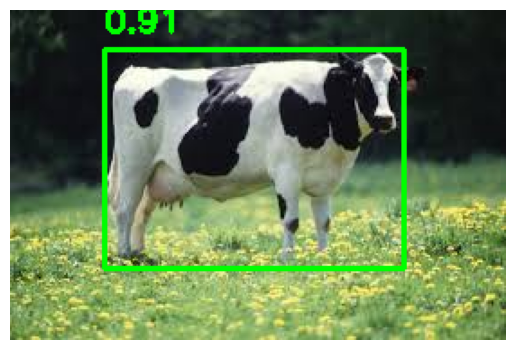

In [19]:
# Checking if YOLO is working fine
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/kaggle/input/test-image-1/cow.jpg")

results = yolo(img)
result = results[0]

for box in result.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    conf = box.conf[0].item()

    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.putText(img, f"{conf:.2f}", (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.show()


## Section 3
### Pipeline and Demo Run

In [20]:
# Loading the saved model
num_classes = 15
model = models.efficientnet_b0(weights=None)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

model_path = "/kaggle/input/result/best_model.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

with open("/kaggle/input/result/breed_labels.json", "r") as f:
    breed_labels = json.load(f)

breed_labels[0]

'Sahiwal'

In [21]:
# Pipeline functions
from PIL import Image
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
])

    
def classifier(image):
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(rgb_image, 'RGB')
    
    trans_image = val_tf(pil_image)
    trans_image = trans_image.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(trans_image)
        probs = torch.softmax(logits, dim = 1)
        conf, idx = probs.max(dim = 1)

    breed_name = breed_labels[idx.item()]
    confidence = conf.item()
    
    return breed_name, confidence
    
def pipeline(image):
    output_image = image.copy()
    
    detection = yolo.predict(image, classes = 19, conf = 0.4)
    for box in detection[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        if x2 <= x1 or y2 <= y1:
            continue
        crop_img = image[y1:y2, x1:x2]
        if crop_img.size == 0:
            continue
        breed, confidence = classifier(crop_img)
        
        cv2.rectangle(
            output_image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )
        label = f"{breed} ({confidence:.2f})"
        text_y = max(25, y1 - 10)
        cv2.putText(
            output_image,
            label,
            (x1, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )
    return output_image


0: 416x640 1 cow, 50.6ms
Speed: 2.1ms preprocess, 50.6ms inference, 22.6ms postprocess per image at shape (1, 3, 416, 640)


/tmp/ipykernel_24/3644506533.py:13: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil_image = Image.fromarray(rgb_image, 'RGB')


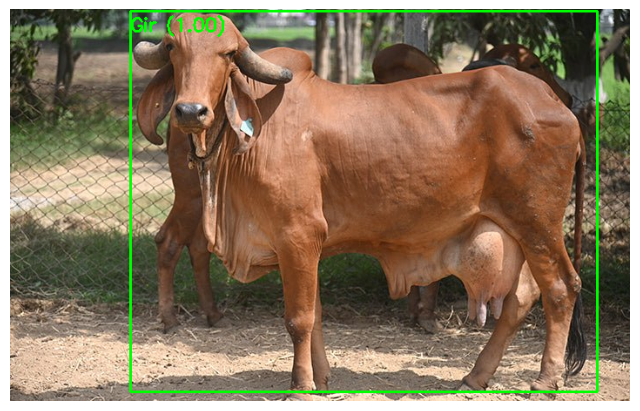

In [22]:
# Demo run
test_image = cv2.imread("/kaggle/input/test-2/ssfd.jpg")
result_image = pipeline(test_image)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()